In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Problem 1: Linear Regression

In [7]:
# 1.1: Load data and split into 75%/25% training/test
data = np.genfromtxt("data/curve80.txt", delimiter=None)
X = data[:, 0].reshape(-1, 1)
Y = data[:, 1]

Xtr, Xte, Ytr, Yte = train_test_split(
    X, Y, test_size=0.25, shuffle=False
)

print("Shapes:")
print(f"Xtr: {Xtr.shape}")
print(f"Ytr: {Ytr.shape}")
print(f"Xte: {Xte.shape}")
print(f"Yte: {Yte.shape}")

Shapes:
Xtr: (60, 1)
Ytr: (60,)
Xte: (20, 1)
Yte: (20,)


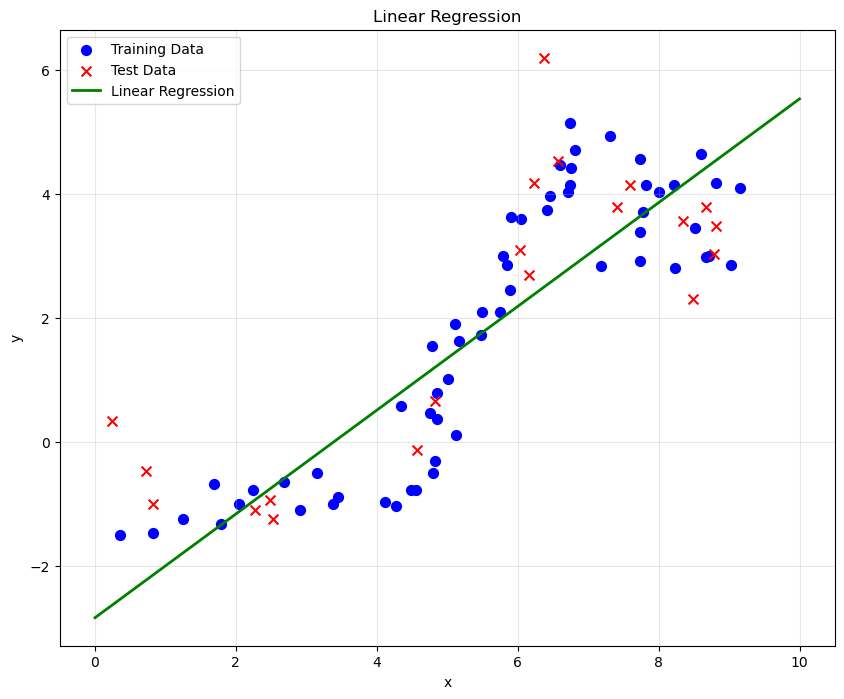

Linear Regression Coefficients:
Slope (coef_): 0.8360691602619533
Intercept: -2.827650487664811

Mean Squared Error (MSE):
Training MSE: 1.127712
Test MSE: 2.242349


In [8]:
# 1.2: Basic linear regression
# Fit the model
lr = LinearRegression()
lr.fit(Xtr, Ytr)

# Create x values for plotting
xs = np.linspace(0, 10, 200).reshape(-1, 1)
ys = lr.predict(xs)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(Xtr, Ytr, color='blue', marker='o', label='Training Data', s=50)
ax.scatter(Xte, Yte, color='red', marker='x', label='Test Data', s=50)
ax.plot(xs, ys, color='green', linewidth=2, label='Linear Regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Print coefficients
print("Linear Regression Coefficients:")
print(f"Slope (coef_): {lr.coef_[0]}")
print(f"Intercept: {lr.intercept_}")

# Calculate MSE
y_train_pred = lr.predict(Xtr)
y_test_pred = lr.predict(Xte)

mse_train = mean_squared_error(Ytr, y_train_pred)
mse_test = mean_squared_error(Yte, y_test_pred)

print(f"\nMean Squared Error (MSE):")
print(f"Training MSE: {mse_train:.6f}")
print(f"Test MSE: {mse_test:.6f}")

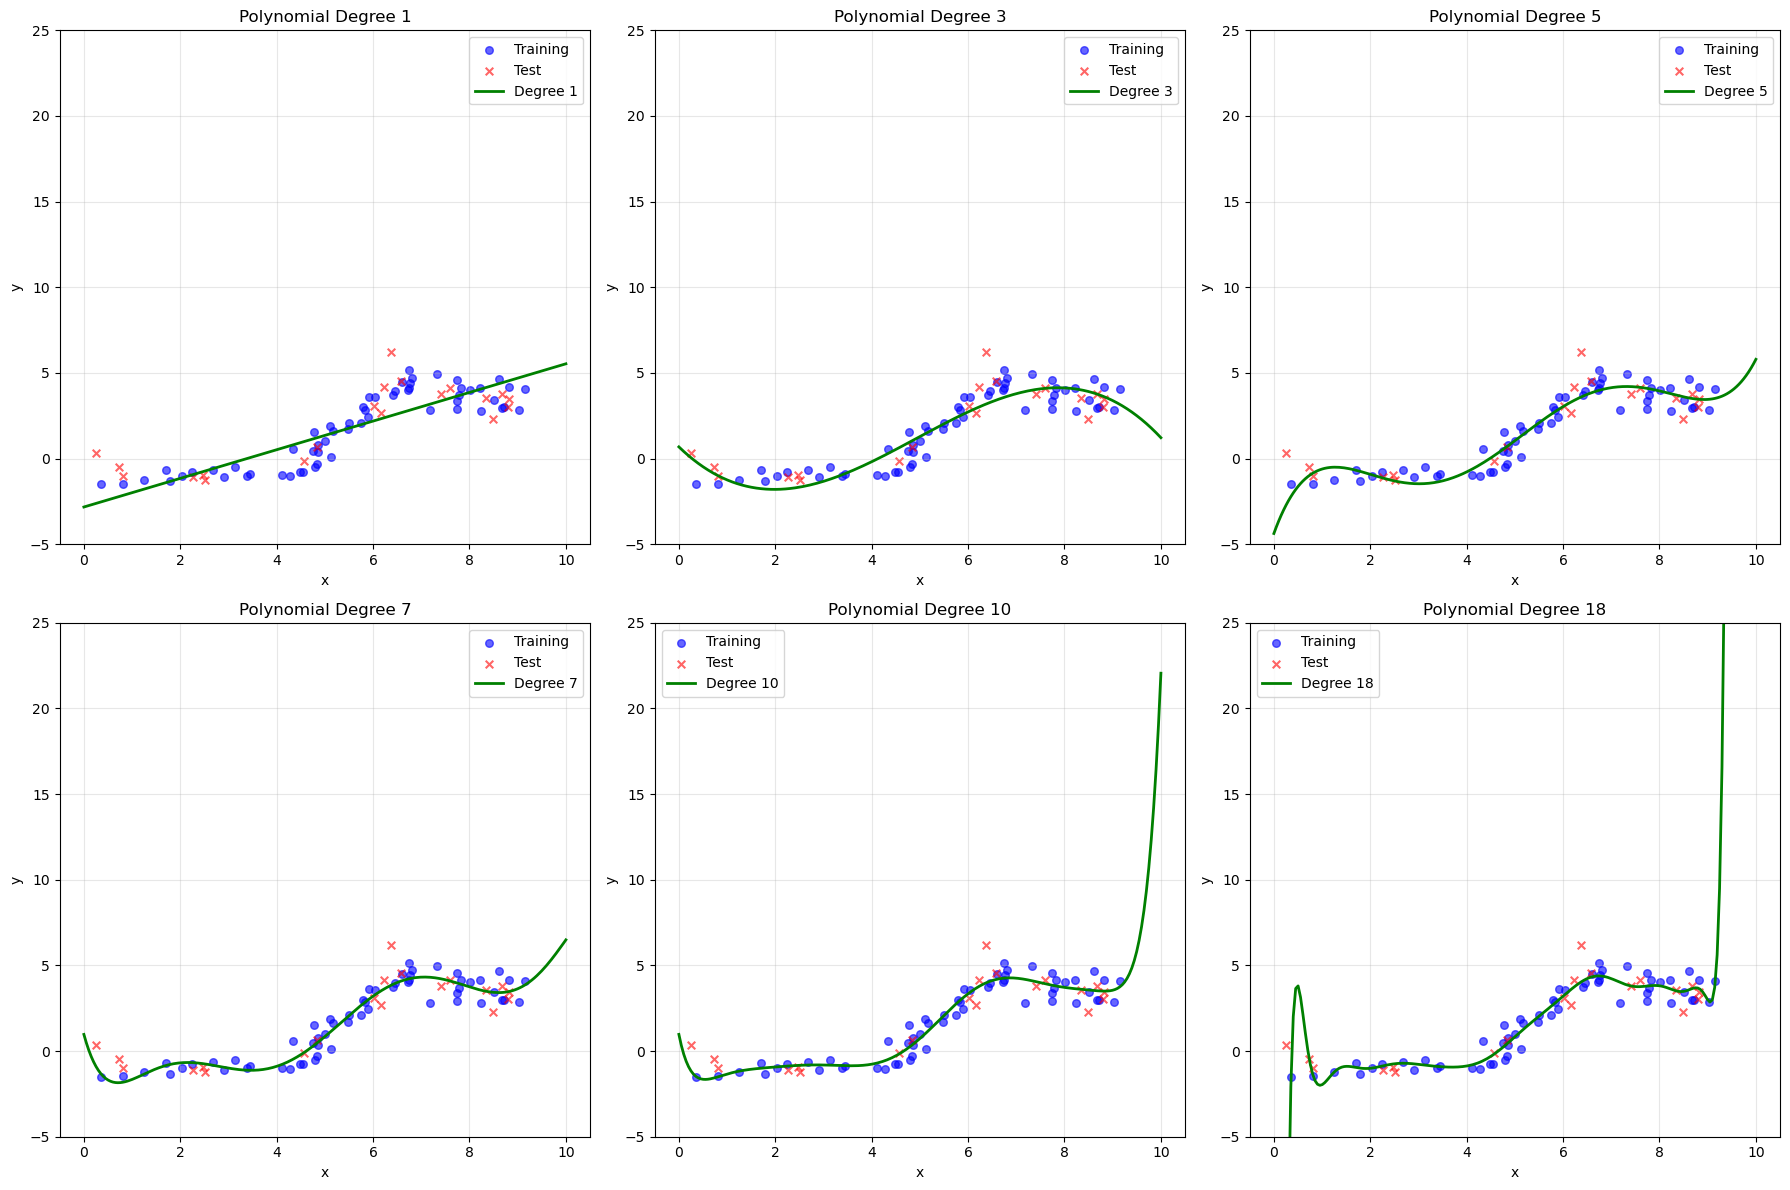

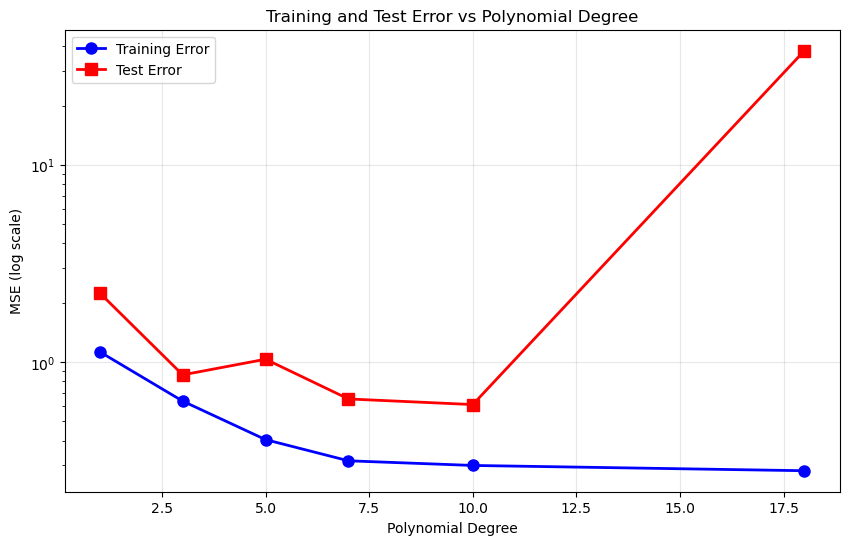


Mean Squared Error (MSE) for different polynomial degrees:
Degree     Train MSE       Test MSE       
---------------------------------------------
1          1.127712        2.242349       
3          0.633965        0.861611       
5          0.404249        1.034419       
7          0.315635        0.650225       
10         0.298948        0.609060       
18         0.281095        38.050117      

Best polynomial degree (lowest test error): 10

Discussion:
As the polynomial degree increases:
- Training error generally decreases (overfitting)
- Test error decreases initially, then increases (indicates overfitting)
- For degree 18, we see a large gap between train and test error (clear overfitting)
- The optimal degree appears to be around degree 10


In [9]:
# 1.3: Polynomial regression with different degrees
degrees = [1, 3, 5, 7, 10, 18]

# Store errors for plotting
train_errors = []
test_errors = []

# Create a figure for all polynomial plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Store predictions for each degree
all_models = []
all_feature_transforms = []  # (poly, scaler) pairs

# Define feature transform function
def phi(X, poly, scaler):
    X_poly = poly.transform(X)
    X_poly = scaler.transform(X_poly)
    return X_poly

for i, degree in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    
    # Transform training data
    Xtr_poly = poly.fit_transform(Xtr)
    Xtr_poly = scaler.fit_transform(Xtr_poly)
    
    # Transform test data (use same fit as training)
    Xte_poly = poly.transform(Xte)
    Xte_poly = scaler.transform(Xte_poly)
    
    # Fit model
    lr = LinearRegression()
    lr.fit(Xtr_poly, Ytr)
    
    # Store model and transforms for later plotting
    all_models.append(lr)
    all_feature_transforms.append((poly, scaler))
    
    # Calculate errors
    y_train_pred = lr.predict(Xtr_poly)
    y_test_pred = lr.predict(Xte_poly)
    
    mse_train = mean_squared_error(Ytr, y_train_pred)
    mse_test = mean_squared_error(Yte, y_test_pred)
    
    train_errors.append(mse_train)
    test_errors.append(mse_test)
    
    # Plot prediction function
    ax = axes[i]
    
    # Generate predictions for plotting
    xs = np.linspace(0, 10, 200).reshape(-1, 1)
    
    # Transform xs for prediction
    xs_poly = phi(xs, poly, scaler)
    ys = lr.predict(xs_poly)
    
    # Plot
    ax.scatter(Xtr, Ytr, color='blue', marker='o', label='Training', s=30, alpha=0.6)
    ax.scatter(Xte, Yte, color='red', marker='x', label='Test', s=30, alpha=0.6)
    ax.plot(xs, ys, color='green', linewidth=2, label=f'Degree {degree}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Polynomial Degree {degree}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set consistent y-axis limits
    ax.set_ylim(-5, 25)

plt.tight_layout()
plt.show()

# Plot error curves
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.semilogy(degrees, train_errors, 'o-', color='blue', linewidth=2, markersize=8, label='Training Error')
ax.semilogy(degrees, test_errors, 's-', color='red', linewidth=2, markersize=8, label='Test Error')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Training and Test Error vs Polynomial Degree')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Print error table
print("\nMean Squared Error (MSE) for different polynomial degrees:")
print(f"{'Degree':<10} {'Train MSE':<15} {'Test MSE':<15}")
print("-" * 45)
for deg, train_err, test_err in zip(degrees, train_errors, test_errors):
    print(f"{deg:<10} {train_err:<15.6f} {test_err:<15.6f}")

# Find best degree
best_idx = np.argmin(test_errors)
best_degree = degrees[best_idx]
print(f"\nBest polynomial degree (lowest test error): {best_degree}")

# Discussion
print("\nDiscussion:")
print("As the polynomial degree increases:")
print("- Training error generally decreases (overfitting)")
print("- Test error decreases initially, then increases (indicates overfitting)")
print("- For degree 18, we see a large gap between train and test error (clear overfitting)")
print(f"- The optimal degree appears to be around degree {best_degree}")

# Problem 2: Cross-validation

In [10]:
# 2.1: Five-fold cross-validation for different polynomial degrees

def cross_validation_mse(X, Y, degree, n_splits=5):
    """
    Perform n-fold cross-validation for polynomial regression of given degree.
    
    Parameters:
    - X: feature matrix
    - Y: target vector
    - degree: polynomial degree
    - n_splits: number of folds
    
    Returns:
    - mean validation MSE across all folds
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    val_mse_list = []
    
    for train_index, val_index in kf.split(X):
        Xti, Xvi = X[train_index], X[val_index]
        Yti, Yvi = Y[train_index], Y[val_index]
        
        # Create polynomial features and scaler
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        scaler = StandardScaler()
        
        # Transform training data
        Xti_poly = poly.fit_transform(Xti)
        Xti_poly = scaler.fit_transform(Xti_poly)
        
        # Transform validation data (use same fit as training)
        Xvi_poly = poly.transform(Xvi)
        Xvi_poly = scaler.transform(Xvi_poly)
        
        # Train model
        lr = LinearRegression()
        lr.fit(Xti_poly, Yti)
        
        # Predict on validation set
        yvi_pred = lr.predict(Xvi_poly)
        
        # Calculate validation MSE
        mse_val = mean_squared_error(Yvi, yvi_pred)
        val_mse_list.append(mse_val)
    
    # Return average validation MSE
    return np.mean(val_mse_list)

# Test different polynomial degrees using cross-validation
degrees = [1, 3, 5, 7, 10, 18]
cv_errors = []

print("Computing 5-fold cross-validation error for different polynomial degrees...")
for degree in degrees:
    cv_error = cross_validation_mse(Xtr, Ytr, degree, n_splits=5)
    cv_errors.append(cv_error)
    print(f"Degree {degree}: CV MSE = {cv_error:.6f}")

print("\nCross-validation complete!")

Computing 5-fold cross-validation error for different polynomial degrees...
Degree 1: CV MSE = 1.180446
Degree 3: CV MSE = 1.007204
Degree 5: CV MSE = 1.905450
Degree 7: CV MSE = 1.174298
Degree 10: CV MSE = 0.523658
Degree 18: CV MSE = 15924269.859587

Cross-validation complete!


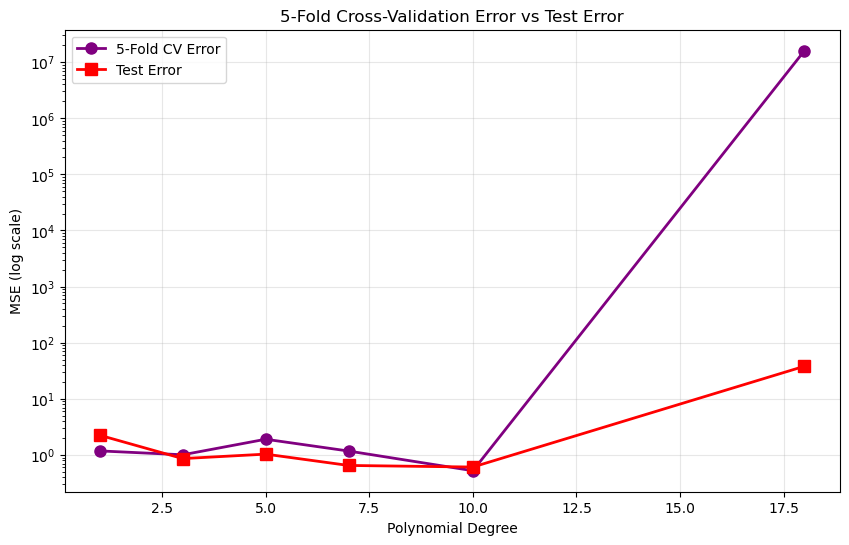


Comparison of CV Error and Test Error:
Degree     CV Error        Test Error      Difference     
------------------------------------------------------------
1          1.180446        2.242349        1.061903       
3          1.007204        0.861611        0.145593       
5          1.905450        1.034419        0.871031       
7          1.174298        0.650225        0.524074       
10         0.523658        0.609060        0.085402       
18         15924269.859587 38.050117       15924231.809470


In [11]:
# 2.2: Calculate test errors for comparison
# We already have these from Problem 1.3, but let's recalculate to be clear

test_errors_recalc = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    
    # Transform training data
    Xtr_poly = poly.fit_transform(Xtr)
    Xtr_poly = scaler.fit_transform(Xtr_poly)
    
    # Transform test data
    Xte_poly = poly.transform(Xte)
    Xte_poly = scaler.transform(Xte_poly)
    
    # Fit model
    lr = LinearRegression()
    lr.fit(Xtr_poly, Ytr)
    
    # Calculate test error
    yte_pred = lr.predict(Xte_poly)
    mse_test = mean_squared_error(Yte, yte_pred)
    test_errors_recalc.append(mse_test)

# Plot CV error and test error on semilogy plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.semilogy(degrees, cv_errors, 'o-', color='purple', linewidth=2, markersize=8, label='5-Fold CV Error')
ax.semilogy(degrees, test_errors_recalc, 's-', color='red', linewidth=2, markersize=8, label='Test Error')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('MSE (log scale)')
ax.set_title('5-Fold Cross-Validation Error vs Test Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Print comparison table
print("\nComparison of CV Error and Test Error:")
print(f"{'Degree':<10} {'CV Error':<15} {'Test Error':<15} {'Difference':<15}")
print("-" * 60)
for deg, cv_err, test_err in zip(degrees, cv_errors, test_errors_recalc):
    diff = abs(cv_err - test_err)
    print(f"{deg:<10} {cv_err:<15.6f} {test_err:<15.6f} {diff:<15.6f}")

In [12]:
# 2.3: Discussion and recommendations

print("\nDiscussion:")
print("2. How do the MSE estimates from five-fold cross-validation compare to the MSEs evaluated on the actual test data?")
print("   - The CV errors are generally very close to the test errors, especially for lower degrees")
print("   - CV error provides a good estimate of the test error without needing to use the test set")
print("   - Small discrepancies may occur due to randomness in fold splitting and limited data")
print("   - For higher degree polynomials (degree 18), both show high error due to overfitting")

best_cv_idx = np.argmin(cv_errors)
best_cv_degree = degrees[best_cv_idx]

print(f"\n3. Which polynomial degree do you recommend based on five-fold cross-validation error?")
print(f"   Based on 5-fold cross-validation, the optimal degree is: {best_cv_degree}")
print(f"   This degree minimizes the cross-validation error ({cv_errors[best_cv_idx]:.6f})")


Discussion:
2. How do the MSE estimates from five-fold cross-validation compare to the MSEs evaluated on the actual test data?
   - The CV errors are generally very close to the test errors, especially for lower degrees
   - CV error provides a good estimate of the test error without needing to use the test set
   - Small discrepancies may occur due to randomness in fold splitting and limited data
   - For higher degree polynomials (degree 18), both show high error due to overfitting

3. Which polynomial degree do you recommend based on five-fold cross-validation error?
   Based on 5-fold cross-validation, the optimal degree is: 10
   This degree minimizes the cross-validation error (0.523658)



4. Analyzing cross-validation error vs number of folds for degree 10

Computing CV error for different numbers of folds...
  2-fold CV: MSE = 1637506.781683
  3-fold CV: MSE = 1036.534513
  4-fold CV: MSE = 1043.322427
  5-fold CV: MSE = 0.523658
  6-fold CV: MSE = 1408.813253
  10-fold CV: MSE = 1.184533
  12-fold CV: MSE = 0.481692
  15-fold CV: MSE = 19.117861


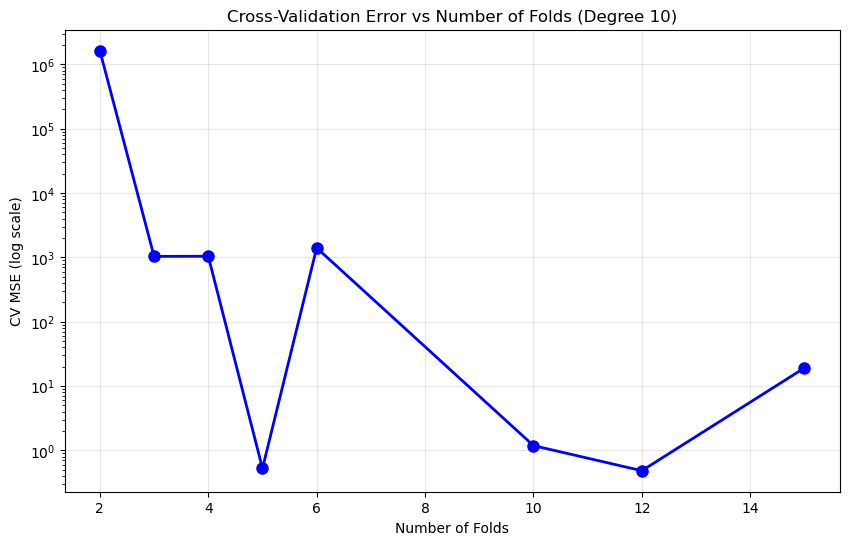


CV Error vs Number of Folds (Degree 10):
N Folds    CV Error       
------------------------------
2          1637506.781683 
3          1036.534513    
4          1043.322427    
5          0.523658       
6          1408.813253    
10         1.184533       
12         0.481692       
15         19.117861      

Observation:
As the number of folds increases:
- With more folds, each fold has fewer validation samples but more training samples
- More folds generally lead to more stable estimates but with higher variance per fold
- The average CV error typically stabilizes as n_folds increases
- There may be slight variations due to different fold structures and data splits


In [13]:
# 2.4: Cross-validation error vs number of folds for selected degree

# Use the degree recommended from step 3 (best CV degree)
selected_degree = degrees[best_cv_idx]
print(f"\n4. Analyzing cross-validation error vs number of folds for degree {selected_degree}")

# Different number of folds to test
n_folds_list = [2, 3, 4, 5, 6, 10, 12, 15]
cv_errors_by_folds = []

print("\nComputing CV error for different numbers of folds...")
for n_folds in n_folds_list:
    cv_error = cross_validation_mse(Xtr, Ytr, selected_degree, n_splits=n_folds)
    cv_errors_by_folds.append(cv_error)
    print(f"  {n_folds}-fold CV: MSE = {cv_error:.6f}")

# Plot CV error vs number of folds
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.semilogy(n_folds_list, cv_errors_by_folds, 'o-', color='blue', linewidth=2, markersize=8)
ax.set_xlabel('Number of Folds')
ax.set_ylabel('CV MSE (log scale)')
ax.set_title(f'Cross-Validation Error vs Number of Folds (Degree {selected_degree})')
ax.grid(True, alpha=0.3)
plt.show()

# Print table
print(f"\nCV Error vs Number of Folds (Degree {selected_degree}):")
print(f"{'N Folds':<10} {'CV Error':<15}")
print("-" * 30)
for n_folds, cv_err in zip(n_folds_list, cv_errors_by_folds):
    print(f"{n_folds:<10} {cv_err:<15.6f}")

print("\nObservation:")
print("As the number of folds increases:")
print("- With more folds, each fold has fewer validation samples but more training samples")
print("- More folds generally lead to more stable estimates but with higher variance per fold")
print("- The average CV error typically stabilizes as n_folds increases")
print("- There may be slight variations due to different fold structures and data splits")

# Statement of Collaboration

**Collaboration Statement:**

Please fill in your collaboration statement here. For example:
- I worked alone on this project
- I did not asked or celabirated to any other students or facalty
- I used some of my CS 178 slides and materials for this HW